In [20]:
from langgraph.graph import StateGraph, MessageGraph
from typing import TypedDict, Annotated

In [2]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [66]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import os
from langchain_google_genai import ChatGoogleGenerativeAI

In [123]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
embeddings=GoogleGenerativeAIEmbeddings(model="models/text-embedding-004")
from langchain_google_genai import ChatGoogleGenerativeAI
llm=ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
   

In [8]:
llm.invoke("Hello, Where did Sachin Tendulkar make his second test century?").content

AIMessage(content=[{'type': 'text', 'text': 'Sachin Tendulkar made his second Test century at the **Sydney Cricket Ground (SCG)** in Australia.\n\nHe scored **148 not out** against Australia in January 1992. This innings was particularly significant as he became the youngest batsman to score a Test century in Australia, at the age of 18.', 'extras': {'signature': 'EtcFCtQFAQw51scWH4tY2lHHnrGVOij8u79JTe9xTtt/mraanStj5fBsUaWjLGgJ6oaHATyfJ7tvsc2d1RpGZGb0UsxjkHb5fXCUcDOLgNfCKlnOuaOuBgsD86gND4HmIu6XGNa08HkO76f88REKh+9MzrRpy8UOO/IPK5GdCbxEIOaU4xNyLHb2kLf//k9w9T6v+tRXddMqnhD0Ir8BxbOqdKUEQq/fu4uhhTtPvCr/i5Gh6mkDmpvmT34SHIl+yaMcubWW8vuxnv2BaMGwQdN52dWhaISs0sHPOI473DXNjTHxl1fWvHnAYCETh7UnkO/jrTsgGXctoBNvV8eK/Srih4SgLvaMxbtgcfTzk5E8hNAPifaIK7RYwsWdy64epFyky3b4l+eydNi0RX9VqYeWNMasUJMmG87eATV12acq34Zxc3Kiu5cldgOINh6w6uRQXovT2GVFpr4yMGsSB2Q08r0+mwfiVztScPT0jJO1g8FlfEE0rYKHGsODdDLWcaN0Dgzasb7kTCHQ028I6KzaizV4d5ksCxnSmdQGk912TMY+Ai3vHQBYHuXUqOP1fvtbxfVe4Tj7YciiukSmnYdUihWD7CJz/VjJb4MBlUv3XS523s4B2jDRS

In [97]:
class GraphState(TypedDict):
    messages: list

def LLM(state: GraphState):
    user_input = state["messages"][-1]
    
    # We use the 'version' argument directly. 
    # Also, ensure 'gemini' is spelled correctly.
    llm = ChatGoogleGenerativeAI(
        model="gemini-3-flash-preview", 
        version="v1", 
        google_api_key=os.getenv("GOOGLE_API_KEY")
    )
    
    response = llm.invoke(user_input).content
    return {"messages": state["messages"] + [response]}

def Counter_Token(state: GraphState):
    # 1. Access the list of messages
    message_list = state["messages"]
    
    # 2. Grab the VERY LAST message (the LLM's response)
    # Using [-1] ensures we get the string, not the whole list
    last_response = message_list[-1]
    
    # 3. Now .split() will work because last_response is a string
    token_count = len(last_response.split())
    msg = f"Total number of tokens is {token_count}"
    
    # 4. Return the dictionary to update the state
    return {"messages": state["messages"] + [msg]}

In [98]:
workflow = StateGraph(GraphState)

In [99]:
workflow.add_node("My LLM",LLM)


In [100]:
workflow.add_node("Token Counter",Counter_Token)


In [101]:
workflow.add_edge(START, "My LLM")
workflow.add_edge("My LLM", "Token Counter")
workflow.add_edge("Token Counter", END)

In [102]:
app=workflow.compile()

In [103]:
from IPython.display import display,Image

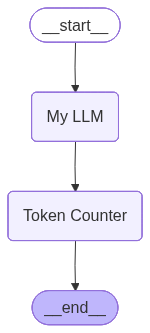

In [104]:
display(Image(app.get_graph().draw_mermaid_png()))

In [109]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
import operator
import os
from langchain_google_genai import ChatGoogleGenerativeAI

# 1. Define State with a Reducer (This is the "Secret Sauce")
# Annotated + operator.add tells LangGraph to ALWAYS append to the list
class GraphState(TypedDict):
    messages: Annotated[list, operator.add]

# 2. Define Nodes
def LLM(state: GraphState):
    # state["messages"] is a list, we take the last string
    user_input = state["messages"][-1]
    
    llm = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    
    # Get the response and force it to a string
    response = llm.invoke(user_input)
    response_text = str(response.content) 
    
    # Return as a list so operator.add can append it
    return {"messages": [response_text]}

def Counter_Token(state: GraphState):
    # Grab the last item. We add a check to make sure it's a string.
    last_item = state["messages"][-1]
    
    # If for some reason last_item is still a list, join it into a string
    if isinstance(last_item, list):
        last_item = " ".join(map(str, last_item))
    
    # Now .split() is 100% safe
    token_count = len(str(last_item).split())
    msg = f"Total number of tokens is {token_count}"
    
    return {"messages": [msg]}

# 3. Build Workflow
# Re-initializing here is mandatory to apply the new Annotated State
workflow = StateGraph(GraphState)

workflow.add_node("My LLM", LLM)
workflow.add_node("Token Counter", Counter_Token)

workflow.add_edge(START, "My LLM")
workflow.add_edge("My LLM", "Token Counter")
workflow.add_edge("Token Counter", END)

app = workflow.compile()

# 4. Run
input_dict = {"messages": ["Explain me in a detailed manner what is AGENTIC AI"]}
result = app.invoke(input_dict)

# 5. Display
print("--- FULL CONVERSATION ---")
for m in result["messages"]:
    print(f"\n>> {m}")

--- FULL CONVERSATION ---

>> Explain me in a detailed manner what is AGENTIC AI

>> [{'type': 'text', 'text': 'To understand **Agentic AI**, you first need to distinguish it from the AI we have been using for the past few years (like standard ChatGPT or Claude).\n\nWhile traditional Generative AI is like a **highly knowledgeable consultant** who gives you advice, Agentic AI is like a **highly capable employee** who can actually do the work for you.\n\nHere is a detailed breakdown of what Agentic AI is, how it works, and why it represents the next frontier of technology.\n\n---\n\n### 1. The Definition: What is "Agency"?\nIn philosophy and sociology, "agency" is the capacity of an actor to act in a given environment. \n\n**Agentic AI** refers to AI systems that are not just designed to predict the next word in a sentence, but to **independently pursue goals.** Instead of waiting for a human to provide a step-by-step prompt, an Agentic system is given a "high-level objective" (e.g., "Re

In [111]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_community.document_loaders import TextLoader,DirectoryLoader
from langchain_community.vectorstores import Chroma
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [119]:
loader_kwargs = {'encoding': 'utf-8'}
loader=DirectoryLoader("../data",glob="./*.txt",loader_cls=TextLoader,loader_kwargs=loader_kwargs)
docs=loader.load()
text_splitter=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=200
)
new_docs = text_splitter.split_documents(documents=docs)
doc_strings = [doc.page_content for doc in new_docs]

In [131]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="text-embedding-004",  # Removed 'models/' prefix
    client_options={"api_endpoint": "generativelanguage.googleapis.com/v1"}
)

In [132]:
db = Chroma.from_documents(new_docs, embeddings)

retriever = db.as_retriever(search_kwargs={"k": 3})

GoogleGenerativeAIError: Error embedding content (NOT_FOUND): 404 NOT_FOUND. {'error': {'code': 404, 'message': 'models/text-embedding-004 is not found for API version v1beta, or is not supported for embedContent. Call ListModels to see the list of available models and their supported methods.', 'status': 'NOT_FOUND'}}